# Week 3: Multiple Linear Regression

## Objective

The objective of this experiment is to implement **Multiple Linear Regression** using the Housing dataset. In this experiment, a regression model is built using Scikit-Learn's `LinearRegression()` class to predict house prices based on multiple independent features. The model coefficients and intercept are analyzed to understand the influence of each feature on the target variable. Finally, different visualizations are used to understand the relationship between variables and evaluate the model's predictions.

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

### Load Dataset

In [6]:
df = pd.read_csv("Housing.csv")
df.head()
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


### Dataset Shape

In [7]:
print("Dataset Shape :", df.shape)

Dataset Shape : (545, 13)


### Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


### Missing Values

In [10]:
df.isnull().sum().sum()

np.int64(0)

# Dataset Description

The Housing dataset contains information about different houses and their selling prices.

### Target Variable (Y)

- Price

### Selected Feature Variables (X)

- Area
- Bedrooms
- Bathrooms
- Stories

These four independent variables are selected because they have a significant impact on the selling price of a house.

### Select features and target

In [12]:
X = df[['area','bedrooms','bathrooms','stories']]
y = df['price']

In [21]:
#Create Model
model = LinearRegression()

In [22]:
# Train the model
model.fit(X,y)

LinearRegression()

In [24]:
print('Slope (m):', model.coef_) 
print('Intercept (c):', model.intercept_) 

Slope (m): [3.80024429e+02 1.98295494e+05 1.20018047e+06 5.31595009e+05]
Intercept (c): -282091.2903634589


### Scatter Plot

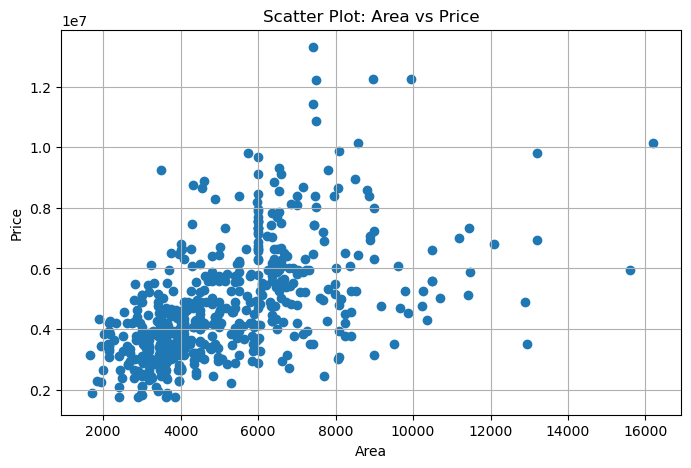

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(df['area'], df['price'])
plt.title("Scatter Plot: Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.grid(True)
plt.show()

### Linear Regression Line

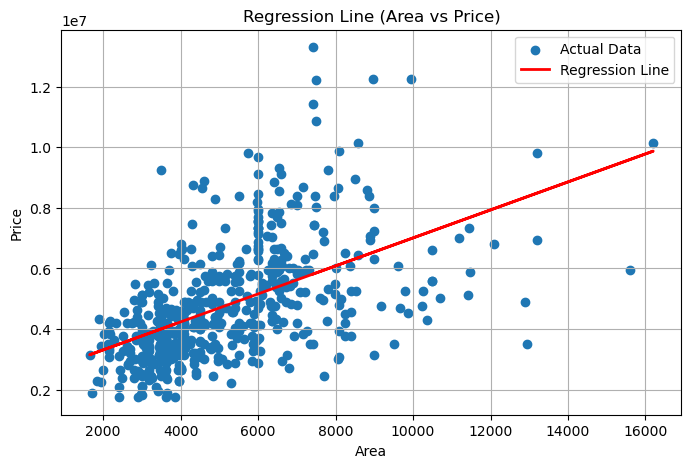

In [27]:
single_feature = df[['area']]
line_model = LinearRegression()
line_model.fit(single_feature, y)
predicted_price = line_model.predict(single_feature)
plt.figure(figsize=(8,5))
plt.scatter(df['area'], y, label="Actual Data")
plt.plot(df['area'], predicted_price, color='red', linewidth=2, label="Regression Line")
plt.title("Regression Line (Area vs Price)")
plt.xlabel("Area")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

###  Implement Gradient Descent

In [30]:
import numpy as np
from sklearn.preprocessing import StandardScaler

In [31]:
# Scale the independent variables

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [32]:
# Number of samples and features

m = X_scaled.shape[0]
n = X_scaled.shape[1]

# Initialize weights and bias

weights = np.zeros(n)
bias = 0

# Hyperparameters

learning_rate = 0.01
epochs = 1000

# List to store loss values

loss_history = []

In [33]:
# Gradient Descent

for epoch in range(epochs):

    # Step 1: Predict values
    y_pred = np.dot(X_scaled, weights) + bias

    # Step 2: Calculate error
    error = y_pred - y

    # Step 3: Calculate loss (Mean Squared Error)
    loss = np.mean(error ** 2)

    # Store loss
    loss_history.append(loss)

    # Step 4: Calculate gradients
    dw = (2/m) * np.dot(X_scaled.T, error)
    db = (2/m) * np.sum(error)

    # Step 5: Update parameters
    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

In [34]:
print("Final Learned Weights\n")

for feature, weight in zip(X.columns, weights):
    print(f"{feature:<12} : {weight:.4f}")

print("\nBias (Intercept):", round(bias,4))

Final Learned Weights

area         : 823949.4559
bedrooms     : 146222.6486
bathrooms    : 602500.0709
stories      : 460729.7436

Bias (Intercept): 4766729.2397


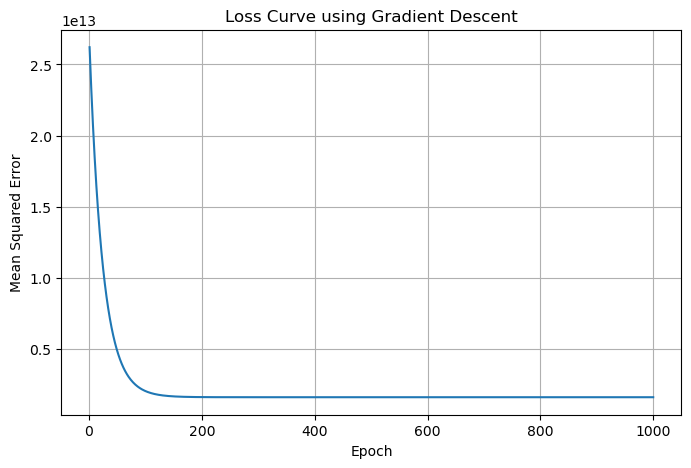

In [36]:
# loss Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1, epochs + 1), loss_history)

plt.title("Loss Curve using Gradient Descent")

plt.xlabel("Epoch")

plt.ylabel("Mean Squared Error")

plt.grid(True)

plt.show()

In [37]:
# Prediction
gd_predictions = np.dot(X_scaled, weights) + bias

print("First 10 Predictions:\n")

print(gd_predictions[:10])

First 10 Predictions:

[ 7326017.69114341 10843206.69838927  7561387.87754745  6824826.53115973
  5594245.37736382  7295114.09469097  9498618.24192137 11529516.05058671
  5852661.93008699  7024671.61144297]


In [38]:
# Compare with scikit-learn
comparison = {
    "Feature": X.columns,
    "Scikit-Learn": model.coef_,
    "Gradient Descent": weights
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Feature,Scikit-Learn,Gradient Descent
0,area,3.800244e+02,823949.455869
1,bedrooms,1.982955e+05,146222.648562
2,bathrooms,1.200180e+06,602500.070851
3,stories,5.315950e+05,460729.743571


In [39]:
# Compare Intercepts
print("Scikit-Learn Intercept :", model.intercept_)

print("Gradient Descent Bias  :", bias)

Scikit-Learn Intercept : -282091.2903634589
Gradient Descent Bias  : 4766729.239684171
